In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from xgboost import XGBRegressor
import xgboost as xgb

from sklearn import set_config
set_config(display="text")

import matplotlib.pyplot as plt

#### Declaramos las funcionas a utilizar

In [3]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

#### Leemos los datos

In [4]:
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037"]

In [5]:
# Primero
#id_train = "270043001951343334363036"
#id_test = "46004e000251353337353037"

In [6]:
# Segundo
id_train = "4e0031000251353337353037"
id_test = "46004e000251353337353037"

In [7]:
# Tercero
# id_train = "200034001951343334363036"
#id_test = "46005a000351353337353037"

In [8]:
# Cuarto
#id_train = "380033001951343334363036"
#id_test = "46005a000351353337353037" 

In [9]:
# Quinto
#id_test = "270043001951343334363036"
#id_train = "46005a000351353337353037"

In [10]:
# Sexto
#id_train = "4e0031000251353337353037"
#id_test = "46005a000351353337353037"

In [11]:
seq_length = 72
forecast_steps = seq_length 
future_steps = 1
intervalo = "15min"

In [12]:
quitar = ["soil_humidity"]
re_sample = "1h"
cut_train = 0
cut_test = 0

In [13]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"

In [14]:
sensors_data_clean = {id: pd.read_csv(f"../src/datos/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [15]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [16]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [17]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [18]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [19]:
train_dataset = train_dataset.set_index("fecha")
test_dataset = test_dataset.set_index("fecha")

In [20]:
# Eliminamos variables no deseadas
train_dataset = train_dataset.drop(columns=quitar)
test_dataset2 = test_dataset.drop(columns=quitar).copy()
test_dataset = test_dataset.drop(columns=["soil_humidity"])

In [21]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-12 00:00:00,14.5425,989.5700,70.2825,61.8775,0.0,0.0,861.0,0
2018-05-12 01:00:00,13.6025,989.2950,69.0500,63.5750,0.0,0.0,861.0,1
2018-05-12 02:00:00,13.7750,988.8725,67.7350,65.4725,0.0,0.0,861.0,2
2018-05-12 03:00:00,13.2425,988.2500,66.1450,67.6675,0.0,0.0,861.0,3
2018-05-12 04:00:00,14.1700,987.8150,64.3375,67.2800,0.0,0.0,861.0,4


In [22]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-14 00:00:00,10.670000,987.840,0.020000,42.950000,2.410000,0.0,864.0,0
2018-05-14 01:00:00,10.010000,987.845,2.335000,41.695000,0.000000,0.0,864.0,1
2018-05-14 02:00:00,9.293333,987.490,4.346667,45.693333,0.803333,0.0,864.0,2
2018-05-14 03:00:00,11.330000,986.755,13.330000,45.570000,2.410000,0.0,864.0,3
2018-05-14 04:00:00,13.295000,986.590,8.860000,43.707500,3.015000,0.0,864.0,4


In [23]:
#X = train_dataset.drop("battery", axis=1)
X = train_dataset
y = train_dataset["battery"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False) #(75/25)

In [25]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2736, 8), (912, 8), (2736,), (912,))

#### Tunning Hiperparámetros

In [26]:
xgbr_best = XGBRegressor(n_estimators=900, 
                         learning_rate=0.011349717150972789, 
                         subsample=0.7489909950808206,
                         max_depth=3, 
                         colsample_bytree=0.7634476213564084,
                         gamma=0.1488051244585744, 
                         reg_alpha=0.9772037319192796, 
                         reg_lambda=0.3349293310460365)

In [27]:
xgbr_best.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7634476213564084, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0.1488051244585744,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.011349717150972789,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

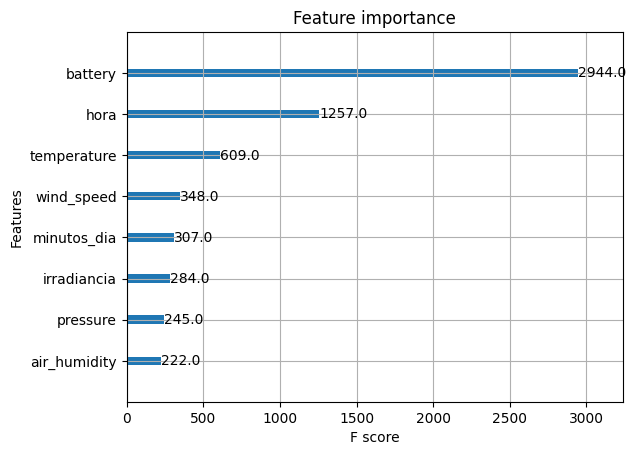

In [28]:
%matplotlib inline

xgb.plot_importance(xgbr_best, ax=plt.gca())

#### Datos entrenamiento

In [29]:
pred_train = xgbr_best.predict(X_train)

In [30]:
print(r2_score(y_train, pred_train)) # Cuanta varianza el modelo explica

0.9992342135750502


In [31]:
print(mean_squared_error(y_train, pred_train))
print(np.sqrt(mean_squared_error(y_train, pred_train)))

0.11833351327518382
0.3439963855554064


In [32]:
print(mean_absolute_error(y_train,pred_train))

0.23548377132787576


#### Datos prueba

In [33]:
pred_test = xgbr_best.predict(X_test)

In [34]:
print(r2_score(y_test, pred_test))

0.9928503534515054


In [35]:
xgbr_best.score(X_test, y_test)

0.9928503534515054

In [36]:
print(mean_squared_error(y_test, pred_test))
print(np.sqrt(mean_squared_error(y_test, pred_test)))

1.4244177749371651
1.1934897464734102


In [37]:
print(mean_absolute_error(y_test,pred_test))

0.600592784491199


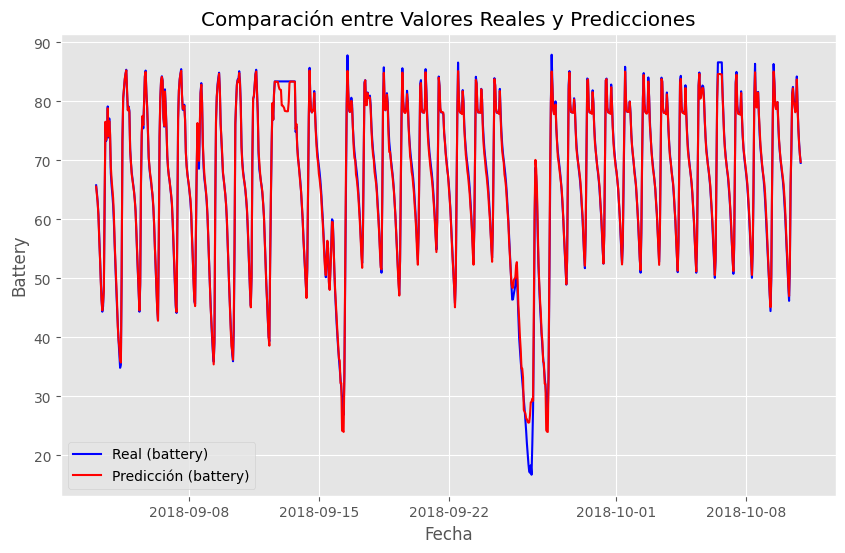

In [38]:
plt.style.use("ggplot")
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test.values, label='Real (battery)', color="blue")
plt.plot(y_test.index, pred_test, label='Predicción (battery)', color="red")
plt.xlabel('Fecha')
plt.ylabel('Battery')
plt.title('Comparación entre Valores Reales y Predicciones')
plt.legend()
plt.grid(True)
plt.savefig("XGBoost_train-B.png", dpi=300, bbox_inches='tight')
plt.show()

## Datos de TEST

In [39]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-14 00:00:00,10.670000,987.840,0.020000,42.950000,2.410000,0.0,864.0,0
2018-05-14 01:00:00,10.010000,987.845,2.335000,41.695000,0.000000,0.0,864.0,1
2018-05-14 02:00:00,9.293333,987.490,4.346667,45.693333,0.803333,0.0,864.0,2
2018-05-14 03:00:00,11.330000,986.755,13.330000,45.570000,2.410000,0.0,864.0,3
2018-05-14 04:00:00,13.295000,986.590,8.860000,43.707500,3.015000,0.0,864.0,4


#### Conjunto de datos nuevo

In [40]:
pred_test2 = xgbr_best.predict(test_dataset)

In [41]:
print(r2_score(test_dataset["battery"], pred_test2))

0.9807322430010446


In [42]:
print(mean_squared_error(test_dataset["battery"], pred_test2))
print(np.sqrt(mean_squared_error(test_dataset["battery"], pred_test2)))

4.977407143186171
2.2310103413445153


In [43]:
print(mean_absolute_error(test_dataset["battery"], pred_test2))

0.7878564127709992


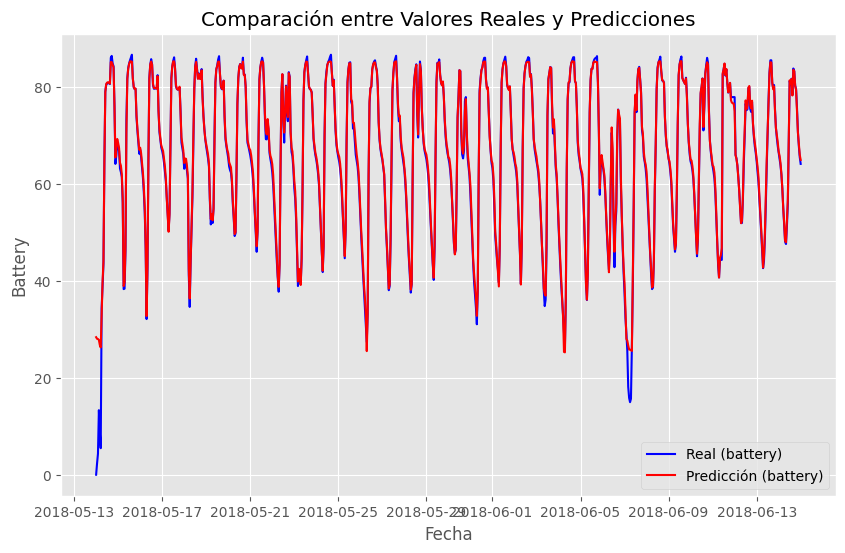

In [44]:
plt.style.use("ggplot")
plt.figure(figsize=(10, 6))
plt.plot(test_dataset.index, test_dataset["battery"].values, label='Real (battery)', color="blue")
plt.plot(test_dataset.index, pred_test2, label='Predicción (battery)', color="red")
plt.xlabel('Fecha')
plt.ylabel('Battery')
plt.title('Comparación entre Valores Reales y Predicciones')
plt.legend()
plt.grid(True)
plt.savefig("XGBoost_test-B.png", dpi=300, bbox_inches='tight')
plt.show()